## Biomarker Analysis for Knee MRI Segmentation

This notebook demonstrates the post-evaluation analysis of finetuned segmentation models by comparing clinically relevant biomarker metrics, such as cartilage thickness and T1ρ, derived from automated inference with those obtained from manual segmentations. It loads evaluation outputs (CSV files generated by the eval_biomarker pipeline) and applies statistical tests (ICC analysis, Bland–Altman plots, regression comparisons) to assess the quality of the automated approach for downstream clinical tasks. The examples, presented in both parametric and nonparametric forms, mirror the methodology used in our study to determine if automated segmentation can effectively replace manual annotations.


In [ ]:
# ---
# Notebook Setup
# ---

import os
import sys
from os.path import join

# # Set the repository root to the parent folder, because this notebook is in demos/
REPO_ROOT = os.path.abspath("..")
print(REPO_ROOT)

os.chdir(REPO_ROOT)
sys.path.insert(0, REPO_ROOT)

from src.evaluation.biomarker_analysis import run_analysis

/data/mskprojects/mskSAM/users/ghoyer/backup_repo/AutoMedLabel


Cleaning data by removing brackets and converting to floats...
Data cleaning completed.


─────────────────────────────────────────────── Shapiro-Wilk Test: ────────────────────────────────────────────────

                                               Shapiro-Wilk Results                                               
┏━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃                      ┃                      ┃                     ┃ Shapiro_Statistic_Pr ┃                     ┃
┃ Class                ┃ Shapiro_Statistic_GT ┃ P_Value_GT          ┃ ed                   ┃ P_Value_Pred        ┃
┡━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ femoral cartilage    │ 0.883672240700154    │ 0.0655719988765643  │ 0.9132057455889534   │ 0.17540352449081487 │
├──────────────────────┼──────────────────────┼─────────────────────┼──────────────────────┼─────────────────────┤
│ lateral tibial       │ 0.974869527338179    │ 0.9341101235439561  │ 0.980429812437547    │ 0.9772199040286936  │
│ cartilage            │                      │                     │                      │                     │
├──────────────────────┼──────────────────────┼─────────────────────┼──────────────────────┼─────────────────────┤
│ medial tibial        │ 0.9347820054565885   │ 0.35555877482483766 │ 0.9592947902813979   │ 0.7114607941261807  │
│ cartilage            │                      │                     │                      │                     │
├──────────────────────┼──────────────────────┼─────────────────────┼──────────────────────┼─────────────────────┤
│ patellar cartilage   │ 0.9408072674161321   │ 0.428766790309689   │ 0.943916743557118    │ 0.4707917354327199  │
└──────────────────────┴──────────────────────┴─────────────────────┴──────────────────────┴─────────────────────┘

────────────────────────────────────────────────── Levene Test: ───────────────────────────────────────────────────

                        Levene Test Results                         
┏━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┓
┃ Class                ┃ Levene_Statistic     ┃ P_Value            ┃
┡━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━┩
│ femoral cartilage    │ 0.015646351768310838 │ 0.9014181119714811 │
├──────────────────────┼──────────────────────┼────────────────────┤
│ lateral tibial       │ 0.008381200681424863 │ 0.9277581693816657 │
│ cartilage            │                      │                    │
├──────────────────────┼──────────────────────┼────────────────────┤
│ medial tibial        │ 0.2134224891883668   │ 0.6479404382151513 │
│ cartilage            │                      │                    │
├──────────────────────┼──────────────────────┼────────────────────┤
│ patellar cartilage   │ 0.000942311329229098 │ 0.975745542660156  │
│                      │ 3                    │                    │
└──────────────────────┴──────────────────────┴────────────────────┘

────────────────────────────────────────────────── ICC Analysis: ──────────────────────────────────────────────────

                                       ICC Results                                       
┏━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃ label                ┃ icc                ┃ ci_lower ┃ ci_upper ┃ description         ┃
┡━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ femoral cartilage    │ 0.9889991508767437 │ 0.9661   │ 0.9965   │ Single fixed raters │
├──────────────────────┼────────────────────┼──────────┼──────────┼─────────────────────┤
│ lateral tibial       │ 0.9959271771669028 │ 0.9874   │ 0.9987   │ Single fixed raters │
│ cartilage            │                    │          │          │                     │
├──────────────────────┼────────────────────┼──────────┼──────────┼─────────────────────┤
│ medial tibial        │ 0.958082392753499  │ 0.875    │ 0.9863   │ Single fixed raters │
│ cartilage            │                    │          │          │                     │
├──────────────────────┼────────────────────┼──────────┼──────────┼─────────────────────┤
│ patellar cartilage   │ 0.9944149252027715 │ 0.9827   │ 0.9982   │ Single fixed raters │
└──────────────────────┴────────────────────┴──────────┴──────────┴─────────────────────┘

────────────────────────────────────────────── Regression Analysis: ───────────────────────────────────────────────

                                                Regression Results                                                 
┏━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Class         ┃ Intercept     ┃ Slope         ┃ R_value        ┃ R_squared     ┃ P_value        ┃ Std_err       ┃
┡━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ femoral       │ 0.07379707543 │ 0.96473159629 │ 0.989312199004 │ 0.97873862709 │ 2.103075278252 │ 0.04104669246 │
│ cartilage     │ 256009        │ 03952         │ 9376           │ 99853         │ 271e-11        │ 141257        │
├───────────────┼───────────────┼───────────────┼────────────────┼───────────────┼────────────────┼───────────────┤
│ lateral       │ 0.07601352544 │ 0.97255985099 │ 0.996214765349 │ 0.99244385870 │ 4.212341385789 │ 0.02449755690 │
│ tibial        │ 86467         │ 38618         │ 6605           │ 06791         │ 806e-14        │ 231349        │
│ cartilage     │               │               │                │               │                │               │
├───────────────┼───────────────┼───────────────┼────────────────┼───────────────┼────────────────┼───────────────┤
│ medial tibial │ -0.1936887733 │ 1.11608581608 │ 0.967830032479 │ 0.93669497176 │ 1.493024007713 │ 0.08375813041 │
│ cartilage     │ 6855328       │ 71574         │ 0895           │ 84754         │ 8267e-08       │ 757707        │
├───────────────┼───────────────┼───────────────┼────────────────┼───────────────┼────────────────┼───────────────┤
│ patellar      │ -0.0115749092 │ 1.01470453786 │ 0.994613780058 │ 0.98925657148 │ 3.484805991628 │ 0.03052572285 │
│ cartilage     │ 50936738      │ 16453         │ 4914           │ 22412         │ 733e-13        │ 359709        │
└───────────────┴───────────────┴───────────────┴────────────────┴───────────────┴────────────────┴───────────────┘

────────────────────────────────────────── Generate Bland-Altman Plots: ───────────────────────────────────────────

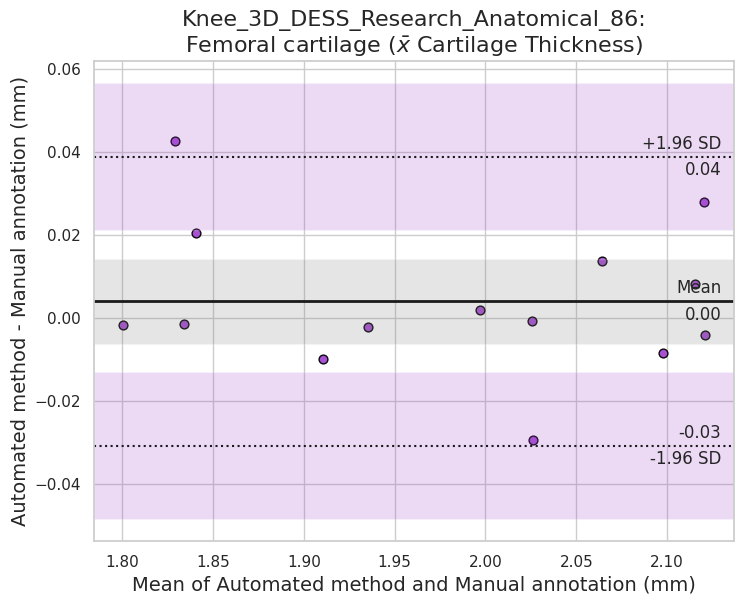

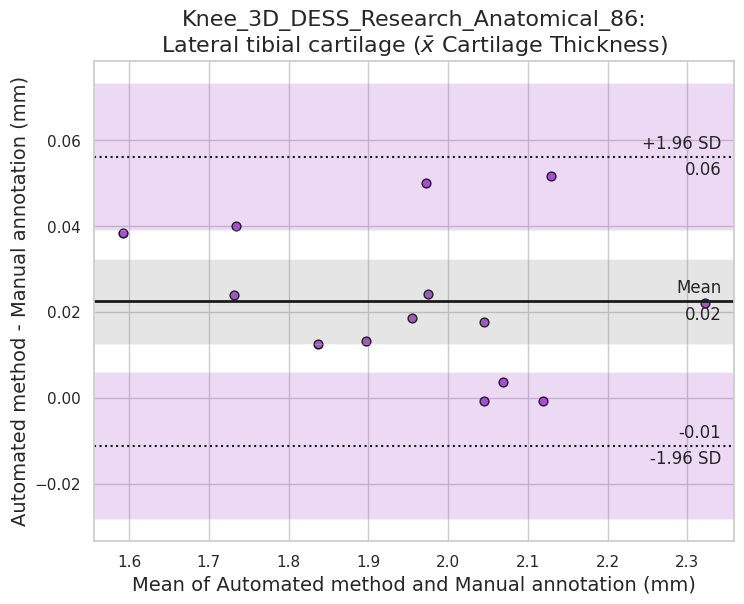

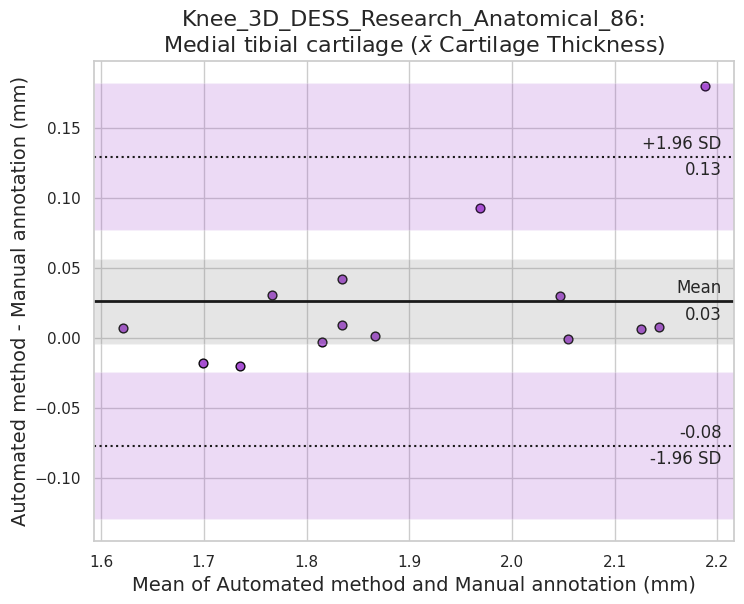

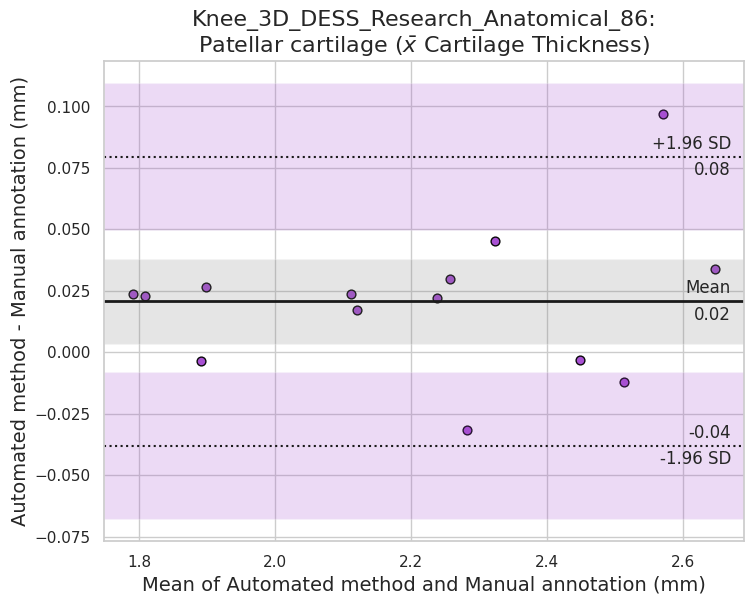

Bland-Altman Complete.


─────────────────────────────────────────── Generate Regression Plots: ────────────────────────────────────────────

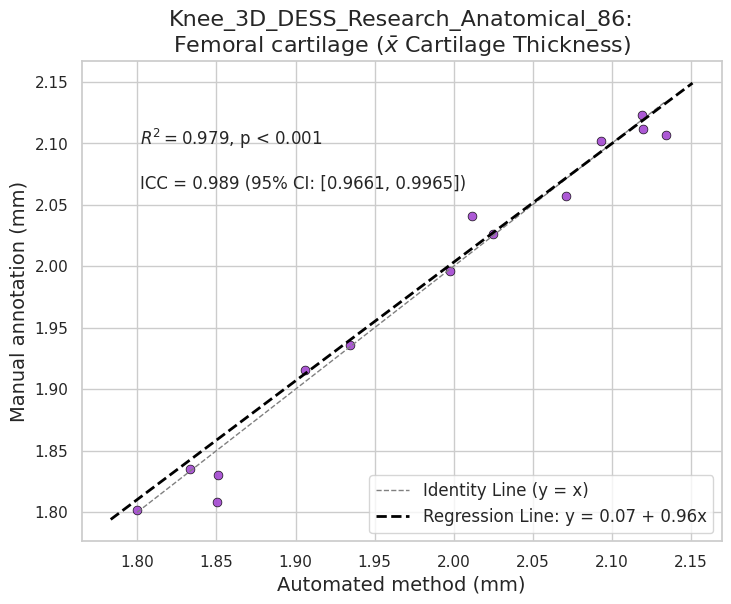

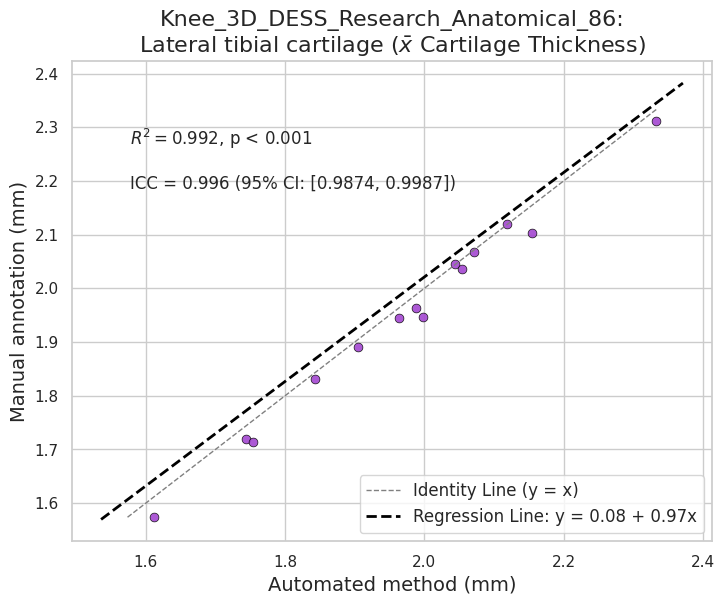

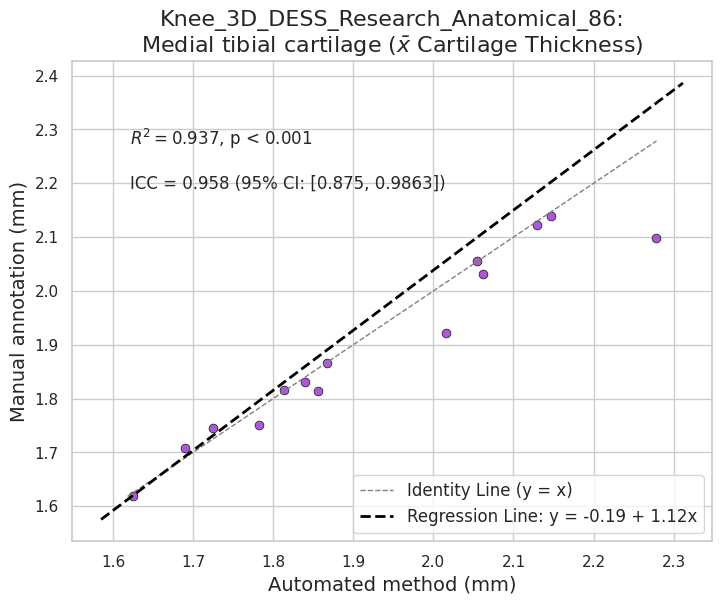

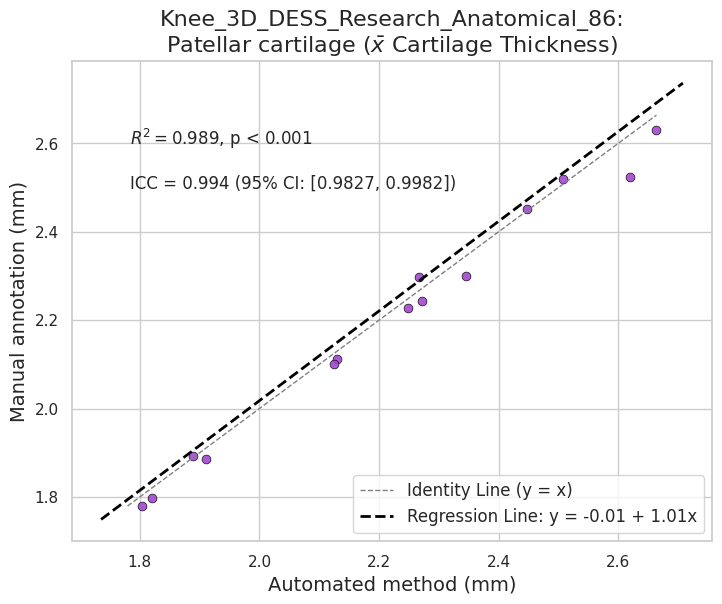

Regression Complete.


In [2]:

# Example: Define or load a configuration dictionary inline.
# (You can also load from a YAML file if desired.)
config = {
    'dataset_name': 'Knee_3D_DESS_Research_Anatomical_86',
    'biomarker': r'$\bar{x}$ Cartilage Thickness',
    'gt_slice_path': join(REPO_ROOT, 'demos', 'demo_data', 'OAI_Knee_cart_thickness', 'cartilagethicknessmetric_gt_slice_volume.csv'),
    'gt_subject_path': join(REPO_ROOT, 'demos', 'demo_data', 'OAI_Knee_cart_thickness', 'cartilagethicknessmetric_gt_volume.csv'),
    'pred_slice_path': join(REPO_ROOT, 'demos', 'demo_data', 'OAI_Knee_cart_thickness', 'cartilagethicknessmetric_pred_slice_volume.csv'),
    'pred_subject_path': join(REPO_ROOT, 'demos', 'demo_data', 'OAI_Knee_cart_thickness', 'cartilagethicknessmetric_pred_volume.csv'),
    'columns': ['femoral cartilage', 'lateral tibial cartilage', 'medial tibial cartilage', 'patellar cartilage'],
    'subject_column': 'Subject',
    'output_dir': join(REPO_ROOT, 'work_dir', 'evaluation', 'stats', 'OAI_Knee_cart_thickness', 'subject'),
    'dot_color': '#4BB98A',
    'move_text': True,
    'clean_data': True,
    'units': 'mm'
}

# Choose the analysis type: 'parametric' or 'nonparametric'
analysis_type = 'parametric'

# Run the analysis. This function will read the configuration and perform the analysis,
# saving output files (such as CSVs and plots) to the specified output directory.
run_analysis(config, analysis_type=analysis_type)

Cleaning data by removing brackets and converting to floats...
Data cleaning completed.


────────────────────────────────────────── Spearman's Rank Correlation: ───────────────────────────────────────────

                  Spearman's Rank Correlation                   
┏━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┓
┃ Variable        ┃ Spearman's rho      ┃ p-value              ┃
┡━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━┩
│ medial femoral  │ 0.42857142857142866 │ 0.337368311085824    │
├─────────────────┼─────────────────────┼──────────────────────┤
│ lateral femoral │ 0.9642857142857145  │ 0.000454149169194168 │
│                 │                     │ 9                    │
├─────────────────┼─────────────────────┼──────────────────────┤
│ lateral tibial  │ 0.6785714285714287  │ 0.0937502539598313   │
├─────────────────┼─────────────────────┼──────────────────────┤
│ medial tibial   │ 0.7142857142857144  │ 0.07134356146753759  │
├─────────────────┼─────────────────────┼──────────────────────┤
│ trochlear       │ 0.8928571428571429  │ 0.006807187408935392 │
├─────────────────┼─────────────────────┼──────────────────────┤
│ patellar        │ 0.8928571428571429  │ 0.006807187408935392 │
└─────────────────┴─────────────────────┴──────────────────────┘

───────────────────────────────────────────── Bootstrap ICC Analysis: ─────────────────────────────────────────────

Bootstrapping ICC for patellar: 100%|██████████| 1000/1000 [00:15<00:00, 65.53it/s]


                                               Bootstrap ICC Results                                               
┏━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━┓
┃            ┃            ┃            ┃ CI_95%_Low ┃ CI_95%_Upp ┃            ┃          ┃ n_bootstra ┃ n_subject ┃
┃ Label      ┃ Mean_ICC   ┃ Median_ICC ┃ er         ┃ er         ┃ CI_95%     ┃ p_value  ┃ ps         ┃ s         ┃
┡━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━┩
│ medial     │ 0.81218480 │ 0.99742912 │ 0.00011804 │ 0.99947307 │ [0.000     │ 0.000000 │ 1000       │ 7         │
│ femoral    │ 17710603   │ 0863926    │ 9869399662 │ 9331592    │ 0.999]     │          │            │           │
│            │            │            │ 9          │            │            │          │            │           │
├────────────┼────────────┼────────────┼────────────┼────────────┼────────────┼──────────┼────────────┼───────────┤
│ lateral    │ 0.84402097 │ 0.98831974 │ 0.34821289 │ 0.99692568 │ [0.348     │ 0.000000 │ 1000       │ 7         │
│ femoral    │ 50152226   │ 4017523    │ 05426015   │ 72191863   │ 0.997]     │          │            │           │
├────────────┼────────────┼────────────┼────────────┼────────────┼────────────┼──────────┼────────────┼───────────┤
│ lateral    │ 0.84943900 │ 0.99315558 │ 0.23115769 │ 0.99920360 │ [0.231     │ 0.000000 │ 1000       │ 7         │
│ tibial     │ 50165832   │ 40397917   │ 055310084  │ 6780511    │ 0.999]     │          │            │           │
├────────────┼────────────┼────────────┼────────────┼────────────┼────────────┼──────────┼────────────┼───────────┤
│ medial     │ 0.92149719 │ 0.99482824 │ 0.00689234 │ 0.99749955 │ [0.007     │ 0.000000 │ 1000       │ 7         │
│ tibial     │ 50678131   │ 46031657   │ 5940601906 │ 9047527    │ 0.997]     │          │            │           │
│            │            │            │ 5          │            │            │          │            │           │
├────────────┼────────────┼────────────┼────────────┼────────────┼────────────┼──────────┼────────────┼───────────┤
│ trochlear  │ 0.92722437 │ 0.99204362 │ 0.66370068 │ 0.99941199 │ [0.664     │ 0.000000 │ 1000       │ 7         │
│            │ 69571258   │ 11244663   │ 32595108   │ 2344996    │ 0.999]     │          │            │           │
├────────────┼────────────┼────────────┼────────────┼────────────┼────────────┼──────────┼────────────┼───────────┤
│ patellar   │ 0.73084638 │ 0.97997630 │ 0.04799396 │ 0.99222577 │ [0.048     │ 0.000000 │ 1000       │ 7         │
│            │ 40517835   │ 46287874   │ 460167108  │ 41551497   │ 0.992]     │          │            │           │
└────────────┴────────────┴────────────┴────────────┴────────────┴────────────┴──────────┴────────────┴───────────┘

────────────────────────────────────── Non-Parametric Bland-Altman Analysis: ──────────────────────────────────────

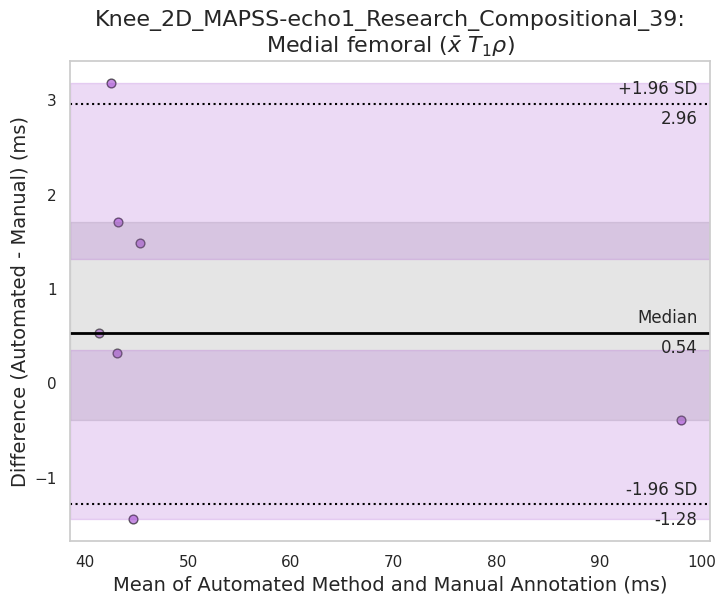

Bland-Altman plot generated for 'medial femoral'.


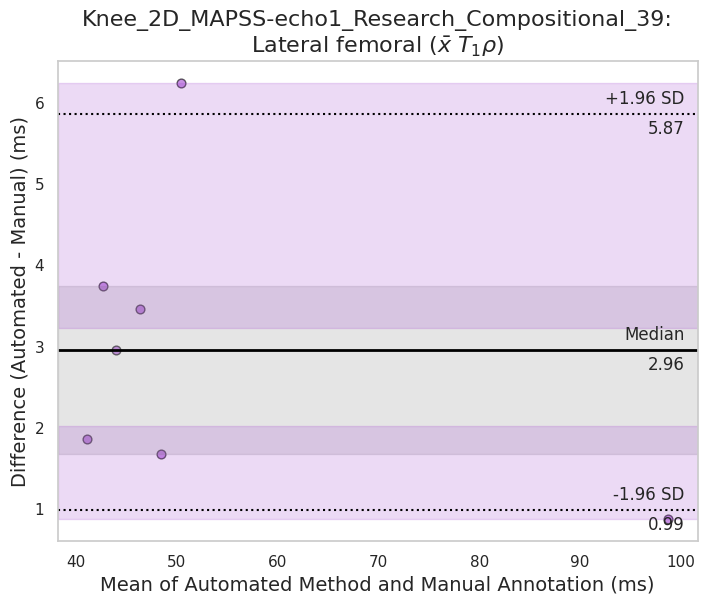

Bland-Altman plot generated for 'lateral femoral'.


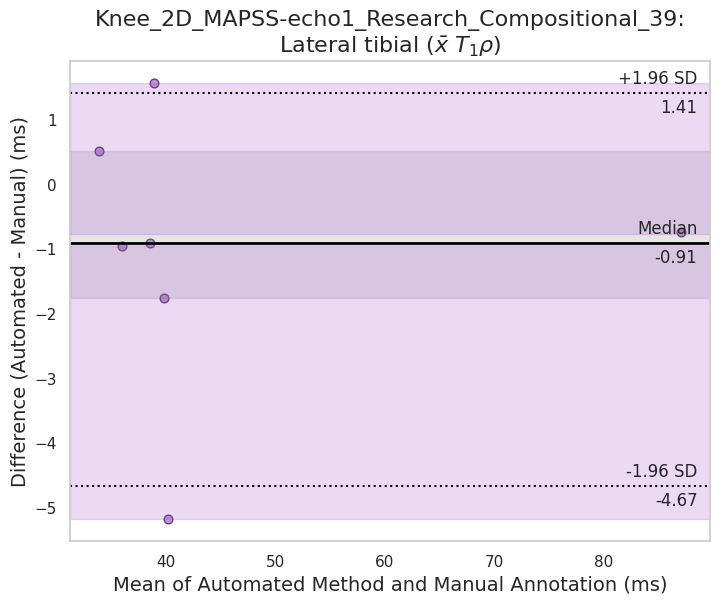

Bland-Altman plot generated for 'lateral tibial'.


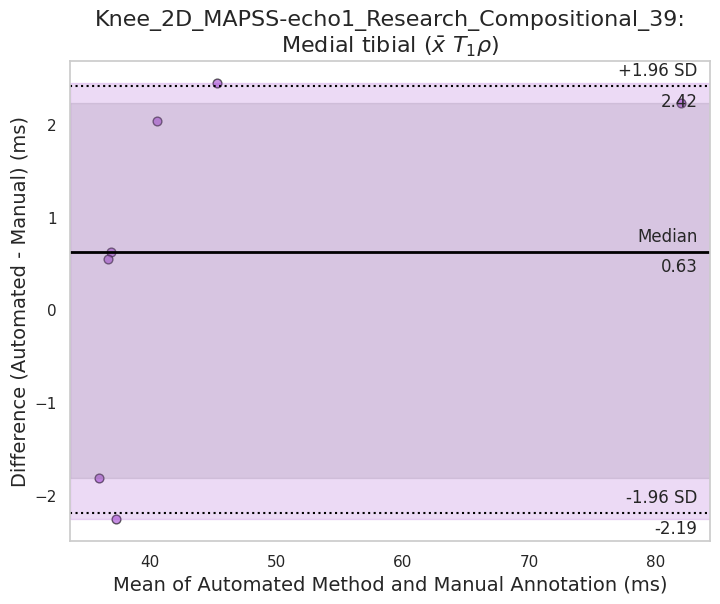

Bland-Altman plot generated for 'medial tibial'.


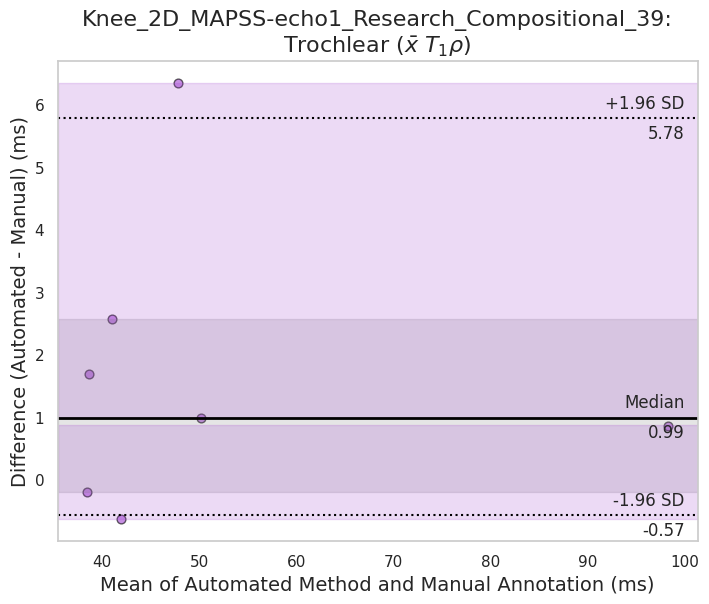

Bland-Altman plot generated for 'trochlear'.


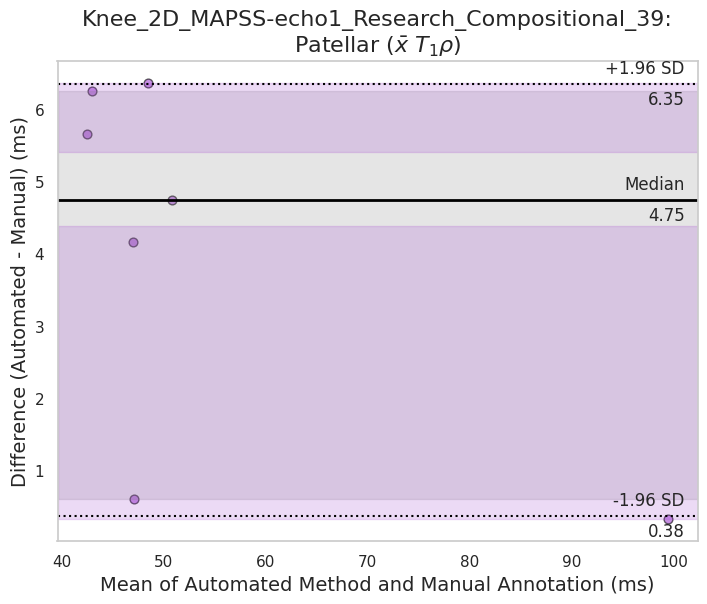

Bland-Altman plot generated for 'patellar'.
Non-parametric Bland-Altman plots generated.


────────────────────────────────────── Gaussian Process Regression Analysis: ──────────────────────────────────────

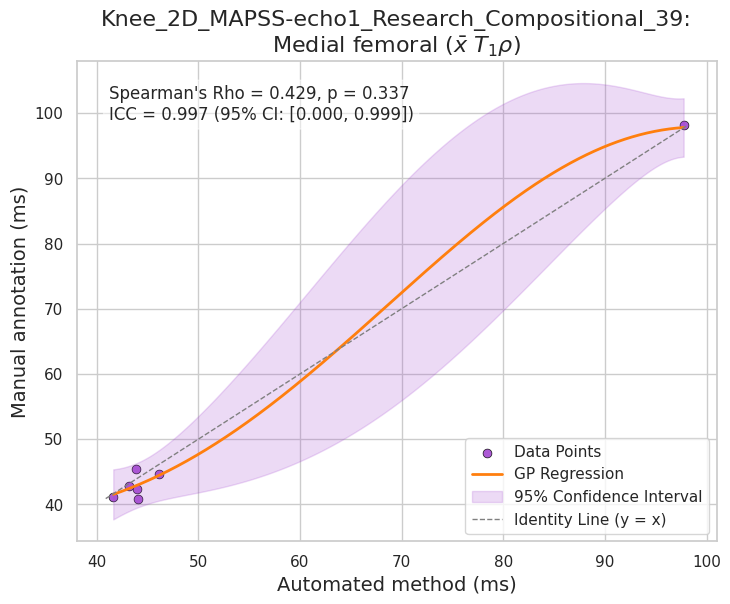

Regression comparison plot generated for 'medial femoral' using Gaussian Process Regression.


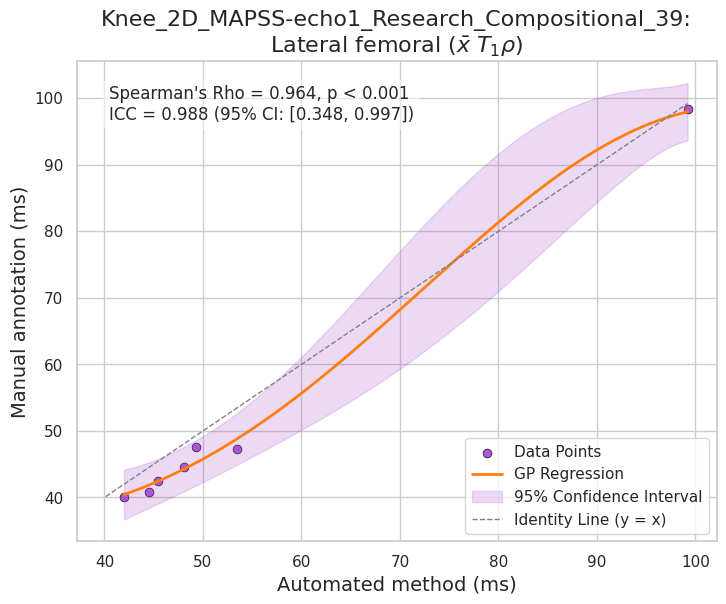

Regression comparison plot generated for 'lateral femoral' using Gaussian Process Regression.


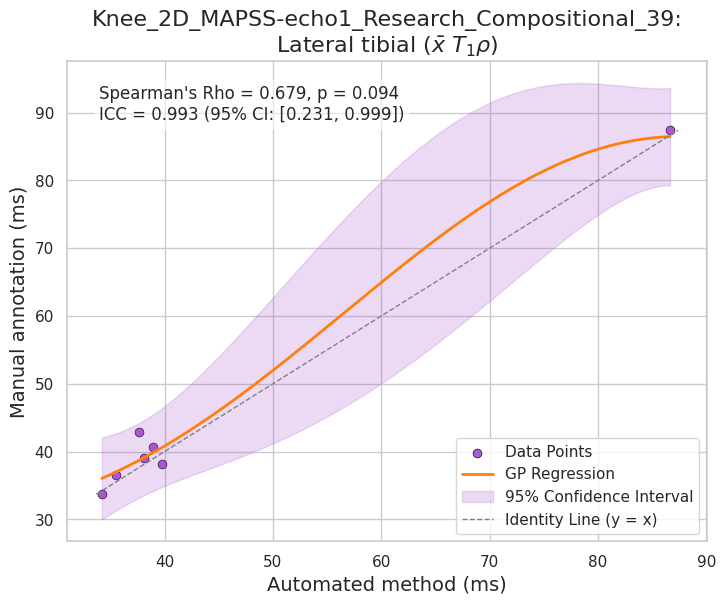

Regression comparison plot generated for 'lateral tibial' using Gaussian Process Regression.


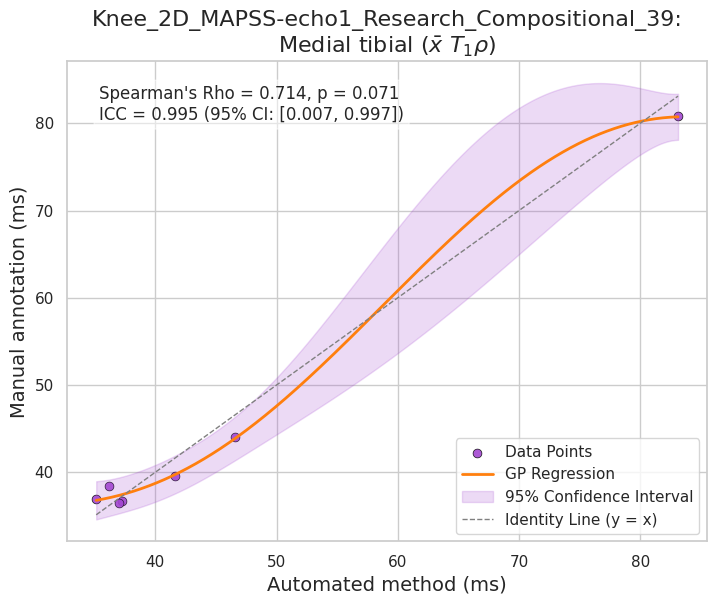

Regression comparison plot generated for 'medial tibial' using Gaussian Process Regression.


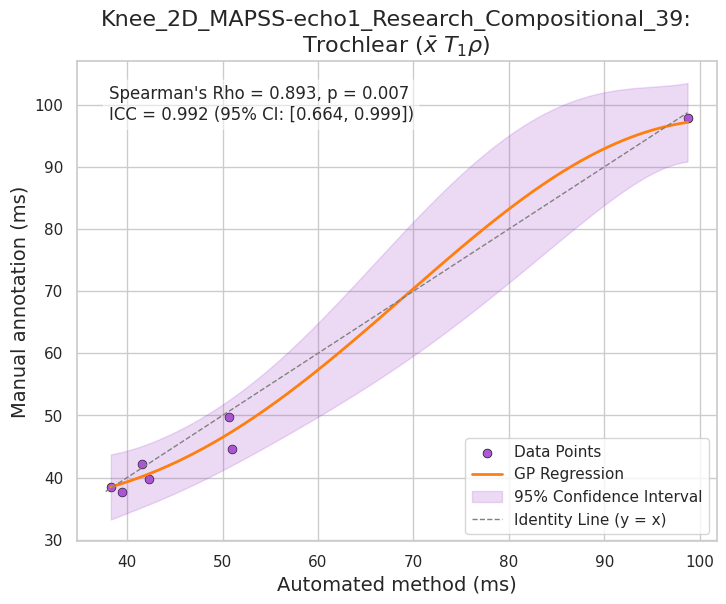

Regression comparison plot generated for 'trochlear' using Gaussian Process Regression.


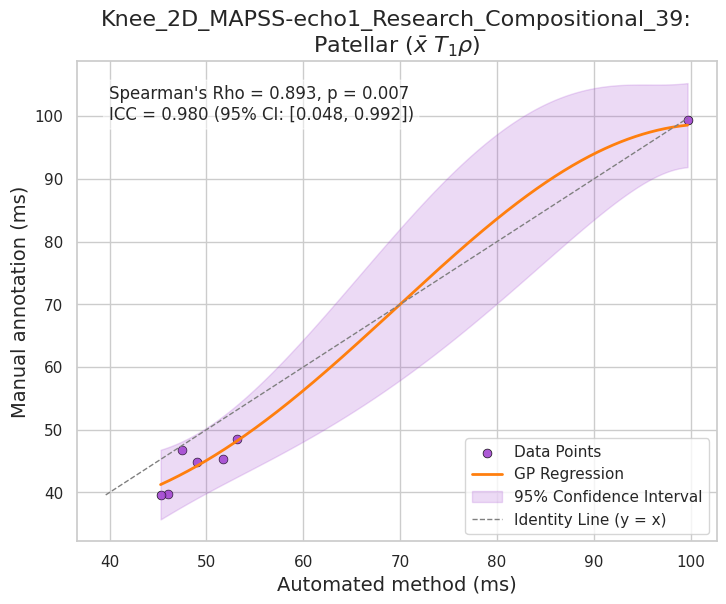

Regression comparison plot generated for 'patellar' using Gaussian Process Regression.
GP regression comparison plots generated.


In [3]:
nonparametric_config = {
        'dataset_name': 'Knee_2D_MAPSS-echo1_Research_Compositional_39',
        'biomarker': r'$\bar{x}$ $T_1\rho$',
        'gt_slice_path': join(REPO_ROOT, 'demos', 'demo_data', 'Knee_T1rho_T2_Mapss', 't1rhometric_gt_slice_volume.csv'),
        'gt_subject_path': join(REPO_ROOT, 'demos', 'demo_data', 'Knee_T1rho_T2_Mapss', 't1rhometric_gt_volume.csv'),
        'pred_slice_path': join(REPO_ROOT, 'demos', 'demo_data', 'Knee_T1rho_T2_Mapss', 't1rhometric_pred_slice_volume.csv'),
        'pred_subject_path': join(REPO_ROOT, 'demos', 'demo_data', 'Knee_T1rho_T2_Mapss', 't1rhometric_pred_volume.csv'),
        'columns': ['medial femoral', 'lateral femoral', 'lateral tibial', 'medial tibial', 'trochlear', 'patellar'],
        'subject_column': 'Subject',
        'n_bootstraps':1000,
        'output_dir': join(REPO_ROOT, 'work_dir', 'evaluation', 'stats', 'Knee_T1rho_T2_Mapss', 'T1Rho', 'subject_non_parametric'),
        'dot_color': '#a347d1',
        'move_text': False,
        'clean_data': True,
        'units': 'ms'
    }

analysis_type = 'nonparametric'

run_analysis(nonparametric_config, analysis_type=analysis_type)
